> `wordcloud` 库支持 **根据掩码图片（mask）的颜色来为词云中的词语着色**，这个功能通过参数 `color_func` 实现，配合 `ImageColorGenerator` 类即可轻松完成
>
> 1. **提供一张彩色图片作为掩码（mask）** ：不仅定义词云的形状，还提供颜色信息。
> 2. **使用** **`ImageColorGenerator`** **从该图片中提取颜色**。
> 3. **将颜色生成器传给** **`WordCloud`** **的** **`color_func`** **参数**。
> 4. 词云中每个词的位置会对应到原图的像素位置，并**采用该位置的颜色**

In [14]:
from os import path
from PIL import Image
import numpy as np

import jieba
import matplotlib.pyplot as plt
import zhplot
from wordcloud import WordCloud, ImageColorGenerator, STOPWORDS

In [11]:
text = open('alice.txt', 'r', encoding='utf-8').read()
# 不是中文不需要分词
# words = jieba.cut(text, cut_all=False)
# words = ' '.join(words)


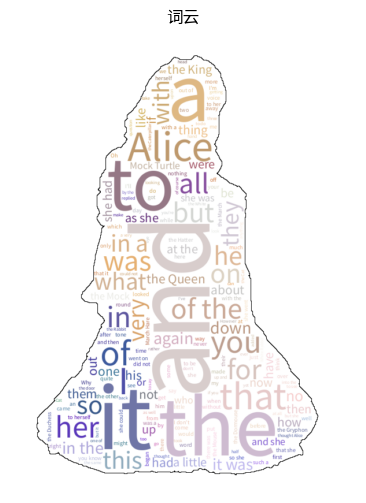

In [28]:
alice_coloring = np.array(Image.open("alice_color.png"))

image_colors = ImageColorGenerator(alice_coloring)

wc = WordCloud(
    mask=alice_coloring,
    background_color="white", 
    contour_width=1,         
    contour_color='black',
    stopwords=['said']
)

wc.generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
# plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("词云")
plt.show()



对比多种情况

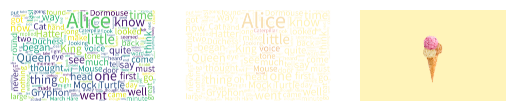

In [ ]:
alice_coloring = np.array(Image.open("low-poly-ice-cream.png"))

stopwords = set(STOPWORDS)
stopwords.add('said')

wc = WordCloud(
    mask=alice_coloring,
    max_words=200,
    max_font_size=400,
    background_color="white", 
    contour_width=1,         
    stopwords=stopwords,
    random_state=42
)

wc.generate(text)

image_colors = ImageColorGenerator(alice_coloring, default_color=(0, 0, 0))

fig, axes = plt.subplots(1, 3)
axes[0].imshow(wc, interpolation="bilinear")
axes[1].imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
axes[2].imshow(alice_coloring, interpolation="bilinear")
for ax in axes:
    ax.set_axis_off()
plt.show()

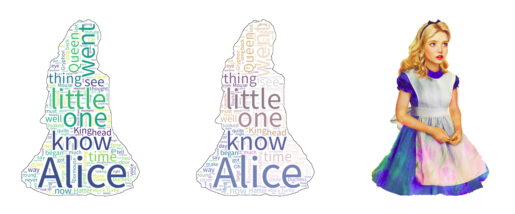

In [ ]:
alice_coloring = np.array(Image.open("alice_color.png"))

stopwords = set(STOPWORDS)
stopwords.add('said')

wc = WordCloud(
    mask=alice_coloring,
    max_words=200,
    max_font_size=400,
    background_color="white", 
    contour_width=1,         
    stopwords=stopwords,
    random_state=42
)

wc.generate(text)

image_colors = ImageColorGenerator(alice_coloring, default_color=(0, 0, 0))

fig, axes = plt.subplots(1, 3)
axes[0].imshow(wc, interpolation="bilinear")
axes[1].imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
axes[2].imshow(alice_coloring, interpolation="bilinear")
for ax in axes:
    ax.set_axis_off()
plt.show()